# Figure2(Stackedbar) for bertopic

In [1]:
bertopic_idx = input("INPUT 'visualization_target for BERTopic RUN_ID'(e.g., 200): ")

print(f'Figure will be drawn based on the run_id_{bertopic_idx} dataset')

Figure will be drawn based on the run_id_200 dataset


In [2]:
tag_idx = input("INPUT 'visualization_target for Tag RUN_ID'(e.g., 100): ")
print(f'Figure will be drawn based on the run_id_{tag_idx} dataset')

Figure will be drawn based on the run_id_100 dataset


In [3]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
from lib.topic_modeling.result_prep import Result_Prep as Result_Prep_Topic
from lib.tag_analysis.result_prep import Result_Prep as Result_Prep_Tag
import lib.visualization.figure_setting as figure_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      sort_distribution_by_list,
                                                      calc_top_bottom_tags_prop)
mpl.rcParams['font.family'] = figure_setting.init_font()
mpl.rcParams.update(figure_setting.fig_setting)


In [4]:
rp_topic = Result_Prep_Topic(bertopic_idx, model_in_run='bert_based')
topic_df = rp_topic.data_prep()
prop_df = proportion_calc_for_topic(topic_df, 'rel_week', 'Topic')
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
            'Bottom 20% Topics' : bot10list, 
            'Mid 60% Topics': mid30list}


topic_proportion_dict = {     'Top 20% Topics'        : sort_distribution_by_list(prop_df, top10list),   
                              'Bottom 20% Topics'     : sort_distribution_by_list(prop_df, bot10list),}

In [5]:
rp_tag = Result_Prep_Tag(tag_idx, model_in_run='tag')
tag_df = rp_tag.data_prep()
tag_proportion_dict = calc_top_bottom_tags_prop(tag_df)

In [6]:
def draw_bar_plot_for_bertopic(ax, i, title, proportion, list_10):
    color_list = Color_Setting.color_list
    alpha_list = [1, 1, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    plotgen = PlotGen()
    ### stacked topic plots
    x = proportion['rel_week'].values
    y = proportion['proportion'].values
    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    _ , p_value = st_chow.chow_test()
    full_title = plotgen.get_title(prefix = None, title_text = title, p_value = p_value)
    plotgen.draw_topic_stack(
        ax,
        full_title,
        proportion,
        list_10,
        color_list[i],
        alpha_list[i],
        ''
    )
    

In [7]:
def draw_bar_plot_for_tag(ax, i, title, proportion):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    alpha_list = [0.6, 0.5, 0.5]
    color_list = ["#a6d96a", "#1a9850", "#1a9850"]
    panel_list = ['A.', 'B.', 'C.', 'D.']
    plotgen = PlotGen()

    x = proportion['rel_week'].values
    y = proportion['pct_pct'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    _ , p_value = st_chow.chow_test()
    full_title = plotgen.get_title(prefix = None, title_text = title, p_value = p_value)
    
    plotgen.draw_tag_bar( ax
                        , full_title 
                        , x
                        , y
                        , color_list[i]
                        , alpha_list[i]
                        , ''
                        , set_ylim = False)
    

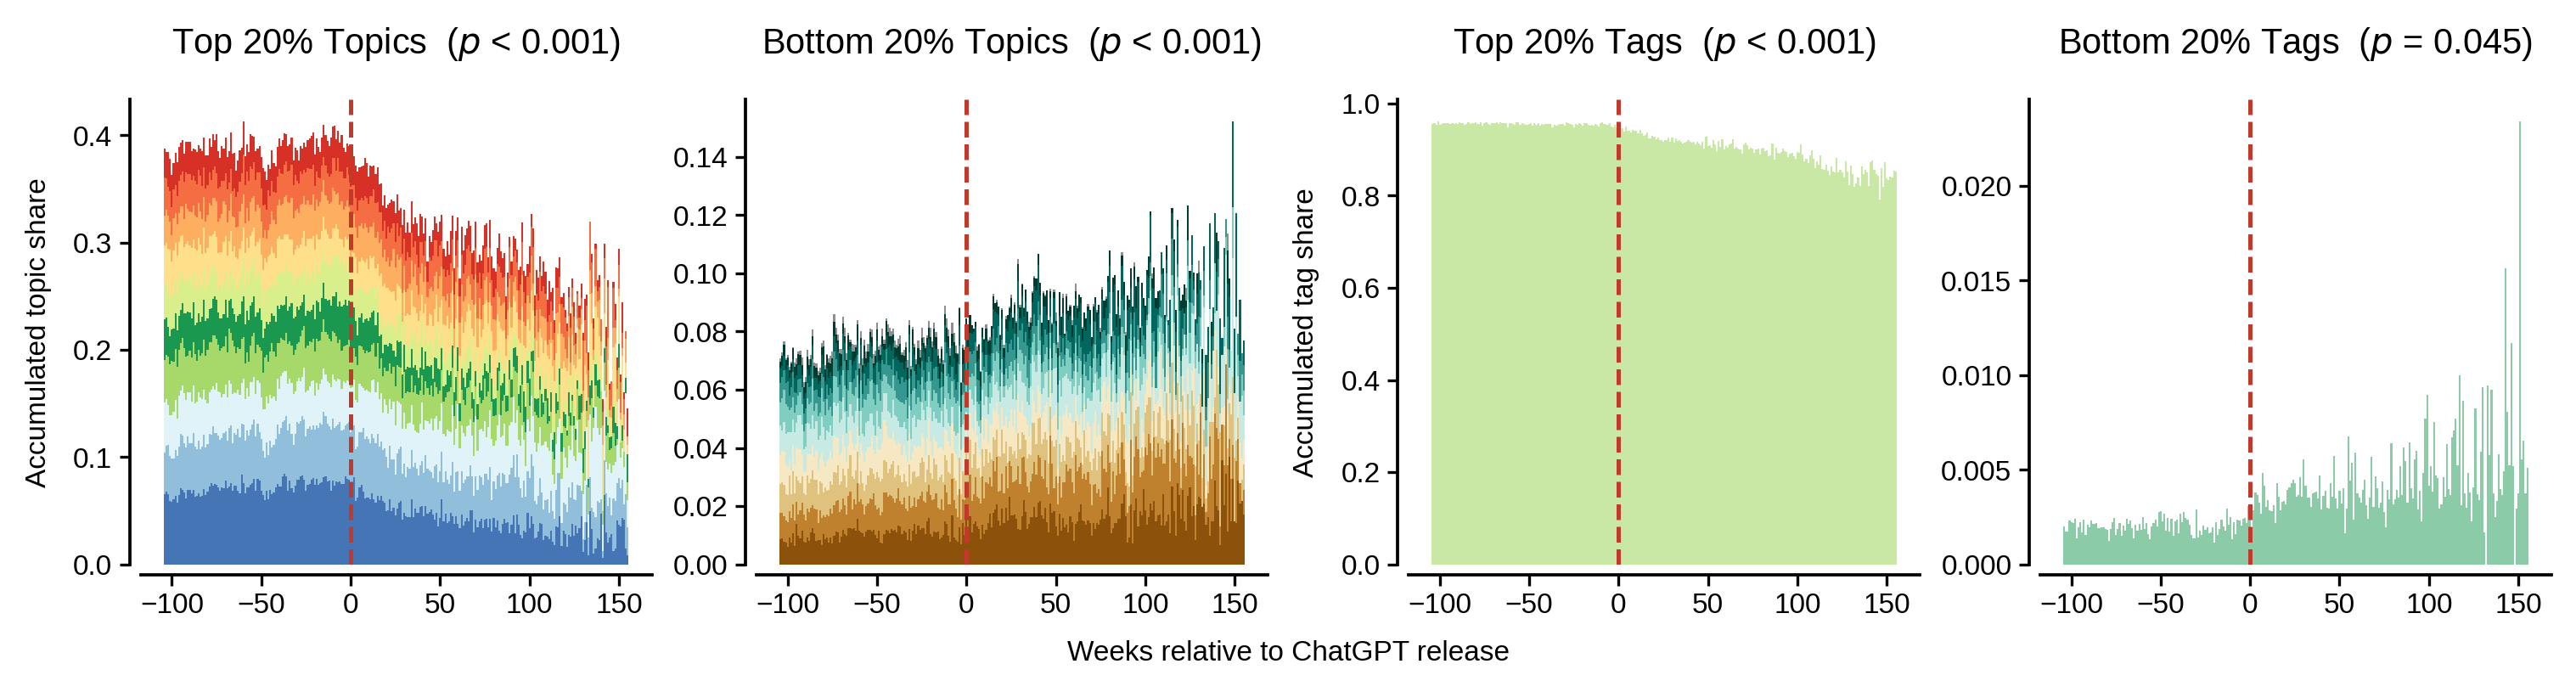

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(10, 2.6), constrained_layout=True,  dpi=300)


base_idx = 0
for i, (title, proportion) in enumerate(topic_proportion_dict.items()):
    draw_bar_plot_for_bertopic(
        ax[base_idx+i],
        i,
        title,
        proportion,
        list_10[title]
    )

base_idx = 2
for i, (title, proportion) in enumerate(tag_proportion_dict.items()):
    draw_bar_plot_for_tag( ax[base_idx+i]
                        , i
                        , f'{title}' 
                        , proportion
    )

ax[0].set_ylabel("Accumulated topic share", labelpad=6)
ax[-2].set_ylabel("Accumulated tag share", labelpad=6)
fig.supxlabel("Weeks relative to ChatGPT release", fontsize=figure_setting.FONT['label'])
plt.savefig('./fig/Fig2.pdf', bbox_inches='tight', dpi=300)

